# Сравнение городских кривых с синтетическими классами топологии

Этот ноутбук сравнивает реальные эпидемические волны городов с синтетическими SEIR-кривыми по форме, а не только через метку классификатора.

Кратко о методе:
- дневные синтетические кривые приводятся к той же 7-точечной недельной шкале, что и городские волны;
- каждая реальная городская волна сравнивается со всеми синтетическими волнами несколькими расстояниями формы;
- класс выбирается по среднему расстоянию до `K_NEAREST` ближайших синтетических кривых каждого класса;
- абсолютная похожесть калибруется на synthetic-to-synthetic сравнениях, чтобы можно было пометить слабые или внераспределительные совпадения.

Важное ограничение: в синтетике используется SEIR-сигнал `I`, а в городах — наблюдаемый недельный ряд `wd_total`. Поэтому результат следует читать как сходство формы с синтетическими классами, а не как доказательство реальной топологии контактной сети.

## 1. Импорты и параметры

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [49]:

ROOT = Path.cwd()
# Общая папка с данными.
DATA_DIR = ROOT / 'data'
RUNS_PATH = DATA_DIR / 'meta' / 'runs.csv'
SIMULATIONS_DIR = DATA_DIR / 'simulations'
# Возможные пути к городским данным. XLSX имеет приоритет, CSV оставлен как fallback.
CITY_DATA_PATH = DATA_DIR / 'indices_in_big_cities.xlsx'

RANDOM_STATE = 42
# Синтетические классы топологии, которые сравниваем с городскими волнами.
GRAPH_KINDS = ['barabasi_albert_graph', 'watts_strogatz_graph']

# Сколько дневных точек синтетики брать до пика.
SYNTHETIC_DAYS_BEFORE_PEAK = 35 + 7
# Сколько дневных точек синтетики брать после пика.
SYNTHETIC_DAYS_AFTER_PEAK = 14 + 7
# Сколько дневных точек агрегируется в одну недельную точку.
DAYS_PER_WEEK_BIN = 7
# Итоговая длина синтетического окна после недельной агрегации.
N_WEEKLY_POINTS = (SYNTHETIC_DAYS_BEFORE_PEAK + SYNTHETIC_DAYS_AFTER_PEAK) // DAYS_PER_WEEK_BIN

# Первый год городских данных, который участвует в анализе.
CITY_START_YEAR = 2010
# Значения в wda_total, которыми помечены эпидемические недели.
EPIDEMIC_MARKS = {'Э'}
# Сколько недель городской волны брать до пика.
CITY_WEEKS_BEFORE_PEAK = 5 + 1
# Сколько недель городской волны брать после пика.
CITY_WEEKS_AFTER_PEAK = 2 + 1
# Итоговая длина городского окна вокруг пика.
CITY_WINDOW_POINTS = CITY_WEEKS_BEFORE_PEAK + CITY_WEEKS_AFTER_PEAK

# Число ближайших синтетических кривых каждого класса для оценки сходства.
K_NEAREST = 25
# Сколько синтетических кривых на класс использовать для калибровки расстояний внутри класса.
CALIBRATION_SAMPLES_PER_CLASS = 250
# Минимальный percentile абсолютной похожести; ниже него совпадение считается слабым.
WEAK_ABSOLUTE_SIMILARITY_PERCENTILE = 10
# Минимальный отрыв лучшего класса от второго; ниже него классификация считается неоднозначной.
WEAK_MARGIN_THRESHOLD = 0.05

## 2. Общие функции для формы кривых

In [50]:
def clean_curve(y):
    '''Приводит ряд к числовому массиву: убирает пропуски, бесконечности и отрицательные значения'''
    arr = pd.to_numeric(pd.Series(y), errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    arr[arr < 0] = 0
    return arr


def normalize_shape(y):
    '''Нормирует кривую на максимум'''
    arr = clean_curve(y)
    if arr.size == 0 or np.nanmax(arr) <= 0:
        return np.zeros_like(arr, dtype=float)
    return arr / np.nanmax(arr)


def fixed_window_around_peak(y, points_before_peak, points_after_peak):
    '''Вырезает фиксированное окно вокруг пика; возвращает пустой ряд, если окно не помещается'''
    arr = clean_curve(y)
    if arr.size == 0 or np.nanmax(arr) <= 0:
        return arr[:0], 0, -1
    peak_idx = int(np.nanargmax(arr))
    start_idx = peak_idx - points_before_peak
    end_exclusive = peak_idx + points_after_peak
    if start_idx < 0 or end_exclusive > arr.size:
        return arr[:0], max(0, start_idx), min(arr.size - 1, end_exclusive - 1)
    return arr[start_idx:end_exclusive], start_idx, end_exclusive - 1


def daily_window_to_weekly_shape(daily_window, days_per_bin=DAYS_PER_WEEK_BIN):
    '''Агрегирует 49 дневных точек синтетики в 7 недельных средних и нормирует форму'''
    arr = clean_curve(daily_window)
    if arr.size != N_WEEKLY_POINTS * days_per_bin:
        return arr[:0]
    weekly = arr.reshape(N_WEEKLY_POINTS, days_per_bin).mean(axis=1)
    return normalize_shape(weekly)


def curve_features(y):
    '''Расчёт признаки формы: площадь, рост, спад и ширину пика'''
    raw = clean_curve(y)
    n = int(raw.size)
    if n == 0:
        return {
            'duration': 0.0, 'auc': 0.0, 'max_growth': 0.0, 'max_decline': 0.0,
            'width_at_half_max': 0.0, 'early_slope': 0.0, 'mean_value': 0.0,
            'std_value': 0.0,
        }

    y_norm = normalize_shape(raw)
    denom = max(n - 1, 1)
    diff = np.diff(y_norm) if n > 1 else np.array([0.0])
    half = np.where(y_norm >= 0.5)[0]
    early_window = max(3, min(n, int(np.ceil(n * 0.35))))
    early_y = y_norm[:early_window]
    early_slope = 0.0
    if early_window >= 2 and np.std(early_y) > 0:
        early_slope = float(np.polyfit(np.arange(early_window, dtype=float), early_y, 1)[0])


    return {
        'duration': float(np.sum(y_norm > 0.05) / n),
        'auc': float(np.trapezoid(y_norm) / denom) if n > 1 else float(y_norm[0]),
        'max_growth': float(np.max(diff)) if diff.size else 0.0,
        'max_decline': float(abs(np.min(diff))) if diff.size else 0.0,
        'width_at_half_max': float((half[-1] - half[0] + 1) / n) if half.size else 0.0,
        'early_slope': early_slope,
        'mean_value': float(np.mean(y_norm)),
        'std_value': float(np.std(y_norm)),
    }


def dtw_distance(a, b):
    '''Считает DTW-расстояние между двумя короткими кривыми с нормировкой на длину пути'''
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    dp = np.full((len(a) + 1, len(b) + 1), np.inf)
    dp[0, 0] = 0.0
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            cost = abs(a[i - 1] - b[j - 1])
            dp[i, j] = cost + min(dp[i - 1, j], dp[i, j - 1], dp[i - 1, j - 1])
    return float(dp[len(a), len(b)] / max(len(a), len(b)))


def distances_to_matrix(query, matrix):
    '''Считает несколько расстояний от одной кривой до матрицы синтетических кривых'''
    q = np.asarray(query, dtype=float)
    x = np.asarray(matrix, dtype=float)
    euclidean = np.sqrt(np.mean((x - q) ** 2, axis=1))

    q_norm = np.linalg.norm(q)
    x_norm = np.linalg.norm(x, axis=1)
    cosine = np.ones(len(x), dtype=float)
    valid_cos = (q_norm > 0) & (x_norm > 0)
    cosine[valid_cos] = 1.0 - (x[valid_cos] @ q) / (x_norm[valid_cos] * q_norm)

    q_center = q - q.mean()
    x_center = x - x.mean(axis=1, keepdims=True)
    q_std = np.linalg.norm(q_center)
    x_std = np.linalg.norm(x_center, axis=1)
    correlation = np.ones(len(x), dtype=float)
    valid_corr = (q_std > 0) & (x_std > 0)
    correlation[valid_corr] = 1.0 - (x_center[valid_corr] @ q_center) / (x_std[valid_corr] * q_std)

    dtw = np.array([dtw_distance(q, row) for row in x], dtype=float)
    return pd.DataFrame({
        'euclidean': euclidean,
        'cosine': cosine,
        'correlation': correlation,
        'dtw': dtw,
    })

## 3. Загрузка синтетических кривых в сопоставимой недельной шкале

In [51]:
runs_df = pd.read_csv(RUNS_PATH)

synthetic_records = []

for row in runs_df.itertuples(index=False):
    source_path = str(row.relative_path)
    graph_kind = str(row.graph_kind)
    curve_path = DATA_DIR / source_path

    curve_df = pd.read_csv(curve_path)

    daily_window, start_idx, end_idx = fixed_window_around_peak(
        curve_df['I'],
        SYNTHETIC_DAYS_BEFORE_PEAK,
        SYNTHETIC_DAYS_AFTER_PEAK,
    )
    weekly_shape = daily_window_to_weekly_shape(daily_window)
    if weekly_shape.size != N_WEEKLY_POINTS or np.nanmax(weekly_shape) <= 0:
        # Пропуск кривых, у которых не получилось извлечь полное недельное окно вокруг пика, или которые оказались пустыми после очистки.
        continue

    feature_row = curve_features(weekly_shape)
    feature_row.update({
        'synthetic_id': len(synthetic_records),
        'label': graph_kind,
        'graph_kind': graph_kind,
        'lam': pd.to_numeric(row.lam, errors='coerce'),
        'seed_in_graph': int(row.seed_in_graph),
        'curve_path': str(curve_path),
        'source_relative_path': source_path,
        'daily_start_idx': start_idx,
        'daily_end_idx': end_idx,
        'shape': weekly_shape,
    })
    synthetic_records.append(feature_row)

synthetic_df = pd.DataFrame(synthetic_records)

synthetic_matrix = np.vstack(synthetic_df['shape'].to_numpy())
print(f'Количество используемых синтетических кривых: {len(synthetic_df):,}')
display(synthetic_df.groupby(['label', 'lam']).size().rename('n').reset_index())

Количество используемых синтетических кривых: 2,866


,label,lam,n
0,barabasi_albert_graph,1.0,244
1,barabasi_albert_graph,2.0,250
2,barabasi_albert_graph,4.0,250
3,barabasi_albert_graph,8.0,250
4,barabasi_albert_graph,16.0,250
5,barabasi_albert_graph,32.0,245
6,barabasi_albert_graph,64.0,156
7,watts_strogatz_graph,1.0,108
8,watts_strogatz_graph,2.0,143
9,watts_strogatz_graph,4.0,181


## 4. Загрузка городских данных и выделение реальных эпидемических волн

In [52]:
def load_city_data(path):
    '''Загружает XLSX/CSV с городскими рядами.'''
    if path.suffix.lower() in {'.xlsx', '.xls'}:
        df = pd.read_excel(path)
    elif path.suffix.lower() == '.csv':
        df = pd.read_csv(path, delimiter=';')

    for column in ['cld_year', 'week_number', 'wd_total', 'qty_total']:
        df[column] = pd.to_numeric(df[column], errors='coerce')
    return (
        df[df['cld_year'] >= CITY_START_YEAR]
        .sort_values(['town_name', 'cld_year', 'week_number'])
        .reset_index(drop=True)
    )


def smooth_city_series(group):
    '''Сглаживает недельный городской ряд wd_total без деления на численность населения.'''
    group = group.sort_values(['cld_year', 'week_number']).copy()
    y = group['wd_total'].astype(float)
    y = y.interpolate(limit_direction='both')
    return y.rolling(window=5, center=True, min_periods=1).median().rolling(window=3, center=True, min_periods=1).mean().to_numpy(dtype=float)


def epidemic_segments(group):
    '''Находит непрерывные интервалы недель, помеченных как эпидемические.'''
    epidemic_mask = (group['wda_total'].astype(str) == "Э").to_numpy()
    
    segments = []
    i = 0
    while i < len(epidemic_mask):
        if not epidemic_mask[i]:
            i += 1
            continue
        start = i
        while i + 1 < len(epidemic_mask) and epidemic_mask[i + 1]:
            i += 1
        end = i
        segments.append((start, end))
        i += 1
    return segments

In [53]:
city_df = load_city_data(CITY_DATA_PATH)
city_wave_records = []
city_wave_curves = []

# Обработка данных по каждому городу
for city, group in city_df.groupby('town_name'):
    # Сортируем данные города по времени
    group = group.sort_values(['cld_year', 'week_number']).reset_index(drop=True)
    
    # Сглаживаем ряд и заполняем пропуски
    smoothed = smooth_city_series(group)
    valid = np.isfinite(smoothed) & (smoothed >= 0)

    # Интерполируем пропущенные значения
    series = pd.Series(np.where(valid, smoothed, np.nan)).interpolate(limit_direction='both').to_numpy(dtype=float)
    
    waves = []

    # Находим все эпидемические периоды
    for epidemic_start_idx, epidemic_end_idx in epidemic_segments(group):
        epidemic_segment = series[epidemic_start_idx:epidemic_end_idx + 1]

        # Находим пик внутри эпидемического периода
        peak_idx = epidemic_start_idx + int(np.nanargmax(epidemic_segment))
        
        # Вычисляем окно вокруг пика
        start_idx = peak_idx - CITY_WEEKS_BEFORE_PEAK
        end_exclusive = peak_idx + CITY_WEEKS_AFTER_PEAK

        # Проверяем, что окно полностью укладывается в данные
        if start_idx < 0 or end_exclusive > len(series):
            continue

        window = series[start_idx:end_exclusive]
        
        # Проверяем корректность окна
        if window.size != CITY_WINDOW_POINTS or np.nanmax(window) <= 0:
            continue

        # Сохраняем информацию о волне
        waves.append({
            'city': city,
            'start_idx': start_idx,
            'end_idx': end_exclusive - 1,
            'peak_idx': peak_idx,
            'epidemic_start_idx': epidemic_start_idx,
            'epidemic_end_idx': epidemic_end_idx,
            'peak_value': float(series[peak_idx]),
            'shape': normalize_shape(window),
        })

    # Формируем финальные записи для каждой волны города
    for wave_id, wave in enumerate(sorted(waves, key=lambda item: item['start_idx']), start=1):
        start_row = group.iloc[wave['start_idx']]
        end_row = group.iloc[wave['end_idx']]
        peak_row = group.iloc[wave['peak_idx']]
        
        features = curve_features(wave['shape'])
        features.update({
            'wave_id': wave_id,
            'city': city,
            'start_year': int(start_row['cld_year']),
            'start_week': int(start_row['week_number']),
            'end_year': int(end_row['cld_year']),
            'end_week': int(end_row['week_number']),
            'peak_year': int(peak_row['cld_year']),
            'peak_week': int(peak_row['week_number']),
            'peak_value': wave['peak_value'],
            'shape': wave['shape'],
        })
        
        city_wave_records.append(features)
        city_wave_curves.append({'city': city, 'wave_id': wave_id, 'shape': wave['shape']})

# Создаём итоговые таблицы
city_waves = pd.DataFrame(city_wave_records)
city_wave_issues = pd.DataFrame(city_wave_issues)

city_matrix = np.vstack(city_waves['shape'].to_numpy())

print(f'Строк после {CITY_START_YEAR} года: {len(city_df):,}')
print(f'Найдено городских волн: {len(city_waves):,}')
display(city_waves[['city', 'wave_id', 'peak_year', 'peak_week', 'peak_value']].head(12))

Строк после 2010 года: 4,380
Найдено городских волн: 42


,city,wave_id,peak_year,peak_week,peak_value
0,Екатеринбург,1,2010,50,9789.0
1,Екатеринбург,2,2011,7,16006.0
2,Екатеринбург,3,2013,6,15750.0
3,Екатеринбург,4,2014,10,13238.0
4,Екатеринбург,5,2015,7,16790.0
5,Казань,1,2010,51,9062.0
6,Казань,2,2011,7,10950.0
7,Казань,3,2013,3,9299.0
8,Казань,4,2014,11,10651.0
9,Казань,5,2015,10,8986.0


## 5. Попарные расстояния между городскими и синтетическими кривыми

In [54]:
pair_parts = []
synthetic_meta = synthetic_df[['synthetic_id', 'label', 'graph_kind', 'lam', 'seed_in_graph', 'source_relative_path']].reset_index(drop=True)

for city_row in city_waves.itertuples(index=False):
    distances = distances_to_matrix(city_row.shape, synthetic_matrix)
    part = pd.concat([synthetic_meta, distances], axis=1)
    part.insert(0, 'city', city_row.city)
    part.insert(1, 'wave_id', city_row.wave_id)
    pair_parts.append(part)

pairwise_distances = pd.concat(pair_parts, ignore_index=True)
DISTANCE_COLUMNS = ['euclidean', 'cosine', 'correlation', 'dtw']

# Приводим разные типы расстояний к общей шкале перед объединением.
distance_scales = {}
for column in DISTANCE_COLUMNS:
    values = pairwise_distances[column].replace([np.inf, -np.inf], np.nan).dropna()
    q25, q75 = values.quantile([0.25, 0.75])
    scale = float(q75 - q25)
    if not np.isfinite(scale) or scale <= 0:
        scale = float(values.std()) if float(values.std()) > 0 else 1.0
    distance_scales[column] = scale
    pairwise_distances[f'{column}_scaled'] = pairwise_distances[column] / scale

SCALED_DISTANCE_COLUMNS = [f'{column}_scaled' for column in DISTANCE_COLUMNS]
pairwise_distances['composite_distance'] = pairwise_distances[SCALED_DISTANCE_COLUMNS].mean(axis=1)

#print(f'Попарных сравнений город-синтетика: {len(pairwise_distances):,}')
#display(pd.Series(distance_scales, name='scale').reset_index().rename(columns={'index': 'distance'}))
#display(pairwise_distances.head())

## 6. Калибровка абсолютной похожести через synthetic-to-synthetic соседей

In [55]:
def composite_from_raw_distances(raw_distances):
    '''Масштабирует отдельные расстояния и объединяет их в одно composite distance.'''
    scaled = raw_distances.copy()
    for column in DISTANCE_COLUMNS:
        scaled[f'{column}_scaled'] = scaled[column] / distance_scales[column]
    return scaled[SCALED_DISTANCE_COLUMNS].mean(axis=1).to_numpy(dtype=float)


def class_knn_score(query_shape, candidate_matrix, candidate_labels, target_label, k=K_NEAREST, exclude_index=None):
    '''Считает среднее composite distance до k ближайших кривых заданного класса.'''
    raw = distances_to_matrix(query_shape, candidate_matrix)
    composite = composite_from_raw_distances(raw)
    mask = np.asarray(candidate_labels) == target_label
    if exclude_index is not None:
        mask[int(exclude_index)] = False
    values = composite[mask]
    if values.size == 0:
        return np.nan
    k_eff = min(k, values.size)
    return float(np.partition(values, k_eff - 1)[:k_eff].mean())

,label,median_same_class_score,p90_same_class_score,p95_same_class_score
0,barabasi_albert_graph,0.063468,0.158940,0.217386
1,watts_strogatz_graph,0.112534,0.346024,0.502542


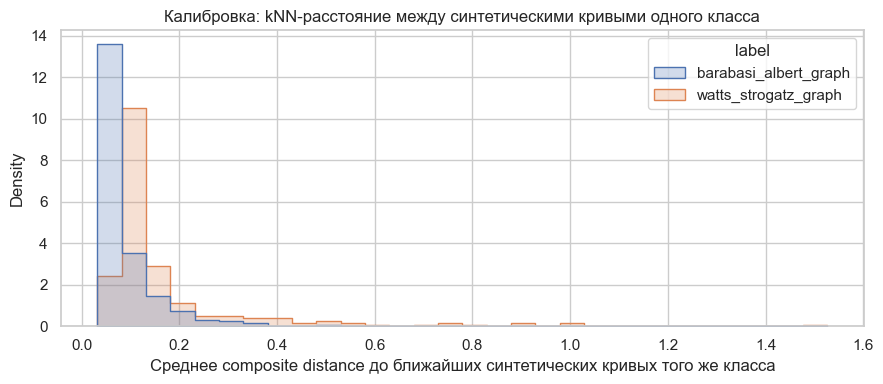

In [56]:
rng = np.random.default_rng(RANDOM_STATE)
calibration_rows = []
labels_array = synthetic_df['label'].to_numpy()

for label, group in synthetic_df.groupby('label'):
    sample_size = min(CALIBRATION_SAMPLES_PER_CLASS, len(group))
    sampled_indices = rng.choice(group.index.to_numpy(), size=sample_size, replace=False)
    for idx in sampled_indices:
        score = class_knn_score(
            synthetic_df.loc[idx, 'shape'],
            synthetic_matrix,
            labels_array,
            label,
            k=K_NEAREST,
            exclude_index=idx,
        )
        calibration_rows.append({'label': label, 'synthetic_id': int(synthetic_df.loc[idx, 'synthetic_id']), 'same_class_knn_score': score})

calibration_scores = pd.DataFrame(calibration_rows).dropna()
calibration_thresholds = (
    calibration_scores
    .groupby('label')['same_class_knn_score']
    .quantile([0.5, 0.9, 0.95])
    .unstack()
    .rename(columns={0.5: 'median_same_class_score', 0.9: 'p90_same_class_score', 0.95: 'p95_same_class_score'})
    .reset_index()
)

display(calibration_thresholds)

plt.figure(figsize=(9, 4))
sns.histplot(data=calibration_scores, x='same_class_knn_score', hue='label', bins=30, element='step', stat='density', common_norm=False)
plt.title('Калибровка: kNN-расстояние между синтетическими кривыми одного класса')
plt.xlabel('Среднее composite distance до ближайших синтетических кривых того же класса')
plt.tight_layout()
plt.show()

## 7. Назначение класса городским волнам по ближайшим синтетическим распределениям

In [57]:
def softmax_from_scores(scores):
    '''Переводит расстояния до классов в относительную меру похожести: меньше расстояние, больше вес.'''
    scores = np.asarray(scores, dtype=float)
    finite = np.isfinite(scores)
    if not finite.any():
        return np.full_like(scores, np.nan, dtype=float)
    temperature = np.nanmedian(scores[finite])
    if not np.isfinite(temperature) or temperature <= 0:
        temperature = 1.0
    logits = -scores / temperature
    logits = logits - np.nanmax(logits[finite])
    probs = np.exp(logits)
    probs[~finite] = np.nan
    return probs / np.nansum(probs)

wave_rows = []
class_score_rows = []

for (city, wave_id), group in pairwise_distances.groupby(['city', 'wave_id']):
    class_scores = []
    for label, class_group in group.groupby('label'):
        nearest = class_group.nsmallest(K_NEAREST, 'composite_distance')
        score = float(nearest['composite_distance'].mean())
        class_scores.append({'label': label, 'score': score})
        class_score_rows.append({
            'city': city,
            'wave_id': wave_id,
            'label': label,
            'knn_composite_distance': score,
            'nearest_composite_distance': float(nearest['composite_distance'].min()),
            'mean_knn_euclidean': float(nearest['euclidean'].mean()),
            'mean_knn_cosine': float(nearest['cosine'].mean()),
            'mean_knn_correlation': float(nearest['correlation'].mean()),
            'mean_knn_dtw': float(nearest['dtw'].mean()),
        })

    score_df = pd.DataFrame(class_scores).sort_values('score')
    probs = softmax_from_scores(score_df['score'].to_numpy())
    score_df['relative_similarity'] = probs
    best = score_df.iloc[0]
    second_score = float(score_df.iloc[1]['score']) if len(score_df) > 1 else np.nan
    margin = second_score - float(best['score']) if np.isfinite(second_score) else np.nan

    calibration_for_label = calibration_scores.loc[calibration_scores['label'] == best['label'], 'same_class_knn_score']
    absolute_similarity_percentile = float((calibration_for_label >= float(best['score'])).mean() * 100.0)

    city_wave_row = city_waves[(city_waves['city'] == city) & (city_waves['wave_id'] == wave_id)].iloc[0]
    wave_rows.append({
        'city': city,
        'wave_id': wave_id,
        'peak_year': int(city_wave_row['peak_year']),
        'peak_week': int(city_wave_row['peak_week']),
        'best_class': str(best['label']),
        'best_knn_composite_distance': float(best['score']),
        'second_best_knn_composite_distance': second_score,
        'distance_margin': margin,
        'relative_similarity': float(best['relative_similarity']),
        'absolute_similarity_percentile': absolute_similarity_percentile,
        'weak_match': bool(
            absolute_similarity_percentile < WEAK_ABSOLUTE_SIMILARITY_PERCENTILE
            or (np.isfinite(margin) and margin < WEAK_MARGIN_THRESHOLD)
        ),
    })

wave_similarity = pd.DataFrame(wave_rows).sort_values(['city', 'wave_id']).reset_index(drop=True)
class_scores = pd.DataFrame(class_score_rows)

city_summary = (
    wave_similarity
    .groupby('city')
    .agg(
        n_waves=('wave_id', 'count'),
        main_class=('best_class', lambda x: x.value_counts().idxmax()),
        main_class_share=('best_class', lambda x: x.value_counts(normalize=True).iloc[0]),
        mean_relative_similarity=('relative_similarity', 'mean'),
        mean_absolute_similarity_percentile=('absolute_similarity_percentile', 'mean'),
        weak_match_share=('weak_match', 'mean'),
    )
    .reset_index()
)

class_score_pivot = (
    class_scores
    .pivot_table(index=['city', 'wave_id'], columns='label', values='knn_composite_distance')
    .reset_index()
)
wave_similarity = wave_similarity.merge(class_score_pivot, on=['city', 'wave_id'], how='left')

#print('Сходство на уровне отдельных волн:')
#display(wave_similarity)
#print('Сводка по городам:')
#display(city_summary)

## 8. Диагностика и визуальная проверка

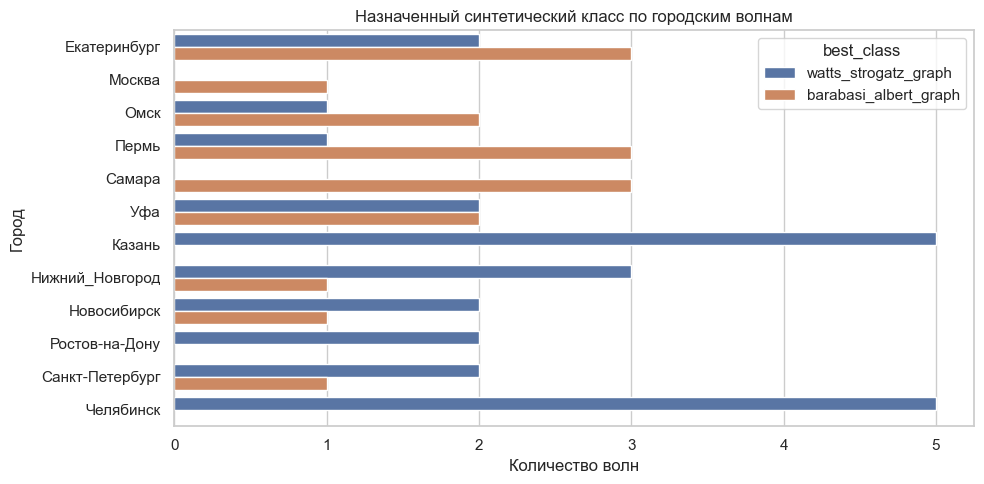

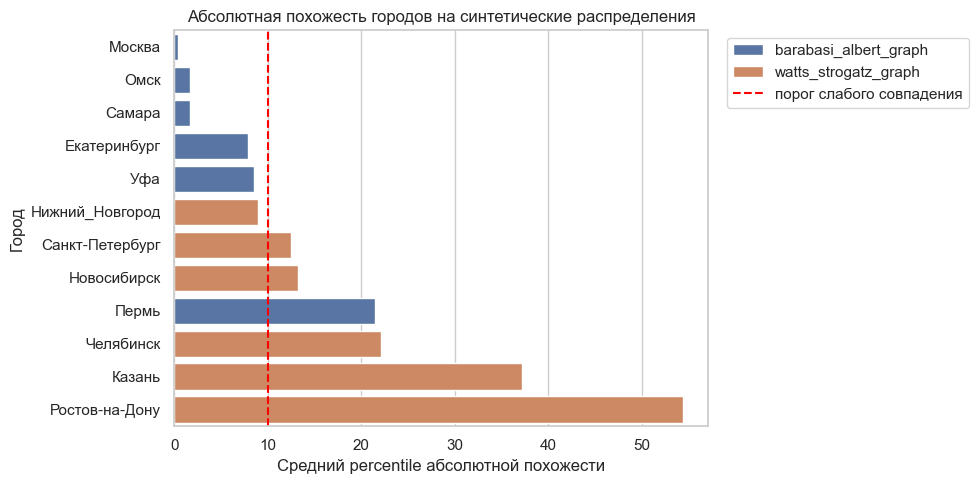

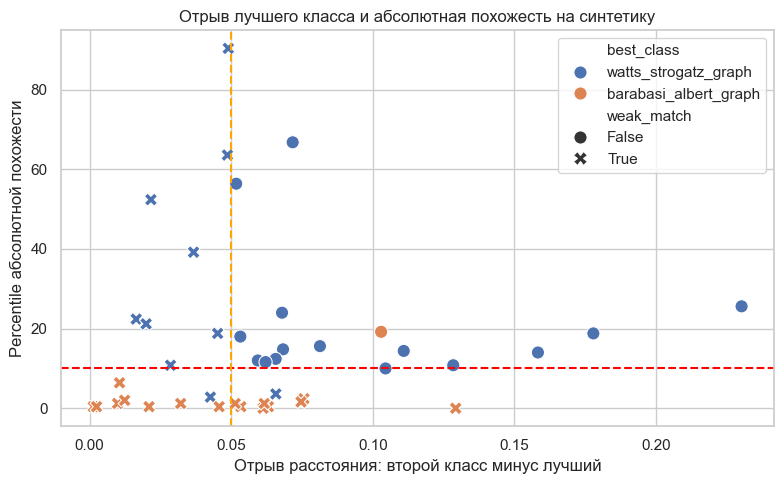

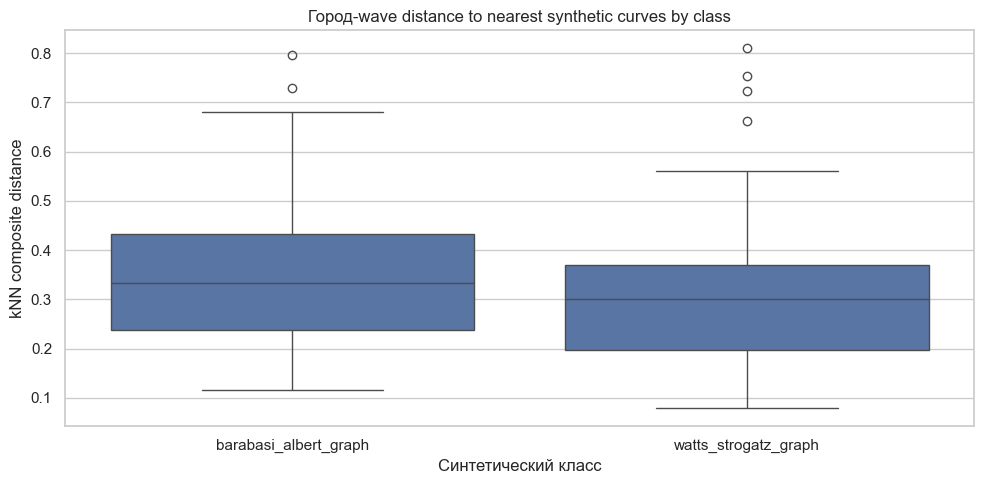

In [58]:
plt.figure(figsize=(10, 5))
sns.countplot(data=wave_similarity, y='city', hue='best_class', order=city_summary.sort_values('main_class').city)
plt.title('Назначенный синтетический класс по городским волнам')
plt.xlabel('Количество волн')
plt.ylabel('Город')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
summary_plot = city_summary.sort_values('mean_absolute_similarity_percentile', ascending=True)
sns.barplot(data=summary_plot, x='mean_absolute_similarity_percentile', y='city', hue='main_class', dodge=False)
plt.axvline(WEAK_ABSOLUTE_SIMILARITY_PERCENTILE, color='red', linestyle='--', label='порог слабого совпадения')
plt.title('Абсолютная похожесть городов на синтетические распределения')
plt.xlabel('Средний percentile абсолютной похожести')
plt.ylabel('Город')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=wave_similarity,
    x='distance_margin',
    y='absolute_similarity_percentile',
    hue='best_class',
    style='weak_match',
    s=90,
)
plt.axhline(WEAK_ABSOLUTE_SIMILARITY_PERCENTILE, color='red', linestyle='--')
plt.axvline(WEAK_MARGIN_THRESHOLD, color='orange', linestyle='--')
plt.title('Отрыв лучшего класса и абсолютная похожесть на синтетику')
plt.xlabel('Отрыв расстояния: второй класс минус лучший')
plt.ylabel('Percentile абсолютной похожести')
plt.tight_layout()
plt.show()

score_long = class_scores.copy()
plt.figure(figsize=(10, 5))
sns.boxplot(data=score_long, x='label', y='knn_composite_distance')
plt.title('Город-wave distance to nearest synthetic curves by class')
plt.xlabel('Синтетический класс')
plt.ylabel('kNN composite distance')
plt.tight_layout()
plt.show()

## 9. Примеры ближайших соседей

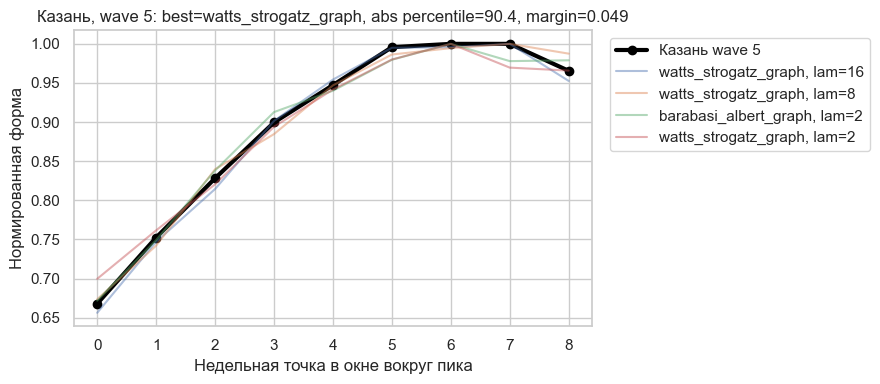

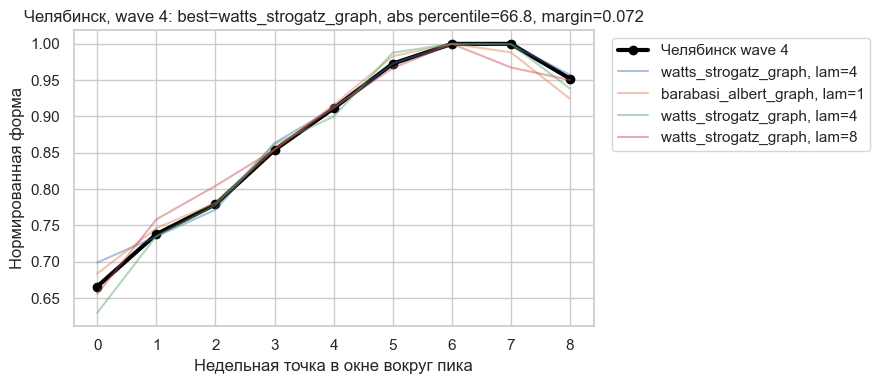

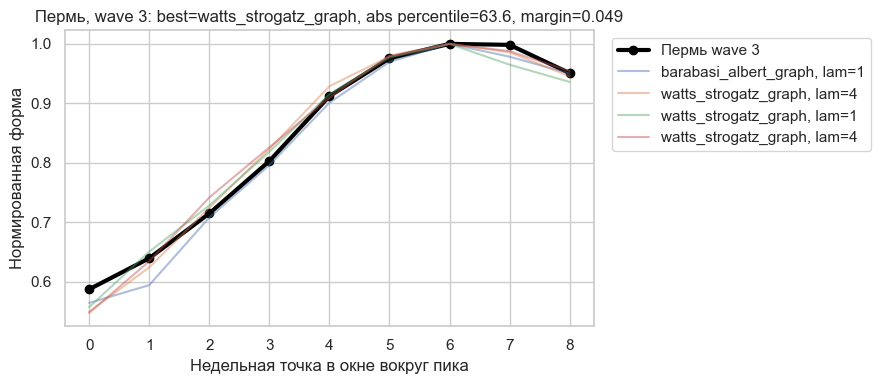

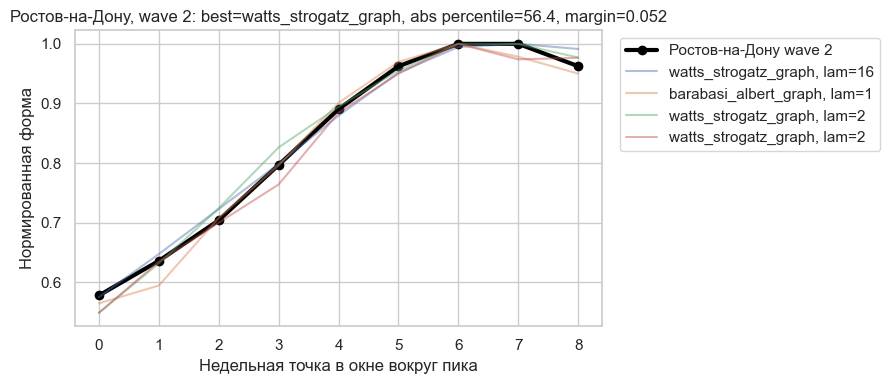

In [59]:
def plot_wave_with_nearest(city, wave_id, n_neighbors=5):
    '''Рисует городскую волну и несколько ближайших синтетических кривых для визуальной проверки.'''
    wave = city_waves[(city_waves['city'] == city) & (city_waves['wave_id'] == wave_id)].iloc[0]
    result = wave_similarity[(wave_similarity['city'] == city) & (wave_similarity['wave_id'] == wave_id)].iloc[0]
    subset = pairwise_distances[(pairwise_distances['city'] == city) & (pairwise_distances['wave_id'] == wave_id)]
    nearest = subset.nsmallest(n_neighbors, 'composite_distance')

    plt.figure(figsize=(9, 4))
    x = np.arange(CITY_WINDOW_POINTS)
    plt.plot(x, wave['shape'], color='black', linewidth=3, marker='o', label=f'{city} wave {wave_id}')
    for row in nearest.itertuples(index=False):
        synthetic_shape = synthetic_df.loc[synthetic_df['synthetic_id'] == row.synthetic_id, 'shape'].iloc[0]
        plt.plot(x, synthetic_shape, alpha=0.45, linewidth=1.5, label=f'{row.label}, lam={row.lam:g}')
    plt.title(
        f'{city}, wave {wave_id}: best={result.best_class}, '
        f'abs percentile={result.absolute_similarity_percentile:.1f}, margin={result.distance_margin:.3f}'
    )
    plt.xlabel('Недельная точка в окне вокруг пика')
    plt.ylabel('Нормированная форма')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

examples = (
    wave_similarity
    .sort_values(['absolute_similarity_percentile', 'distance_margin'], ascending=[False, False])
    .head(4)
)
for row in examples.itertuples(index=False):
    plot_wave_with_nearest(row.city, row.wave_id, n_neighbors=4)

## 10. Как читать результат

Используйте `wave_similarity` для анализа отдельных эпидемических волн и `city_summary` для агрегации по городам.

Ключевые поля:
- `best_class`: синтетический топологический класс с минимальным средним расстоянием до ближайших синтетических кривых;
- `relative_similarity`: относительное предпочтение между двумя доступными синтетическими классами;
- `absolute_similarity_percentile`: насколько типично расстояние городской волны по сравнению с synthetic-to-synthetic расстояниями внутри того же класса;
- `weak_match`: `True`, если реальная волна либо плохо отделяется между классами, либо необычно далека от синтетического распределения.

Если городская волна получила класс, но имеет низкий `absolute_similarity_percentile`, её корректнее описывать как слабо или неоднозначно похожую, а не как уверенно принадлежащую этой топологии.